PHY 573- QFT on 3 Qubits <br>
Nicholas Amore

In [1]:
#initialization
import matplotlib.pyplot as plt
import numpy as np
from numpy import pi
import math
import time

# importing Qiskit
from qiskit import transpile
from qiskit import QuantumCircuit, ClassicalRegister, QuantumRegister
from qiskit_aer import Aer
from qiskit.circuit.library import Initialize

# import basic plot tools
from qiskit.visualization import plot_histogram

In [2]:
#Init circuit for n = 2
n = 3
QFT = QuantumCircuit(n)

in_dat = np.array([0.35+0.02j, -0.32+0j, 0.37 -0.02j, 0.35 - 0.04j, 0.3-0.02j, -0.34+0j, 0.37-0.04j,-0.41+0j])
in_norm = in_dat / np.linalg.norm(in_dat)
init = Initialize(in_norm)
QFT.append(init,[0, 1,2])

In [3]:
# Diffusion operator (U_s)
QFT.h(2)
QFT.cp(pi/2, 1, 2)
QFT.cp(pi/4, 0, 2)
QFT.h(1)
QFT.cp(pi/2, 0, 1)
QFT.h(0)
QFT.swap(0,2)
QFT.measure_all()
QFT.draw()
QFT.draw()

»
   q_0: »
        »
   q_1: »
        »
   q_2: »
        »
meas: 3/»
        »
«        ┌───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐»
«   q_0: ┤0                                                                                                                                  ├»
«        │                                                                                                                                   │»
«   q_1: ┤1 Initialize(0.35012+0.020007j,-0.32011,0.37013-0.020007j,0.35012-0.040014j,0.30011-0.020007j,-0.34012,0.37013-0.040014j,-0.41014) ├»
«        │                                                                                                                                   │»
«   q_2: ┤2                                                                                                                                  ├»
«        └───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┘»
«meas: 3/═════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════»
«                                                                                                                                             »
«                                             ┌───┐    ░ ┌─┐      
«   q_0: ───────────────■─────────────■───────┤ H ├─X──░─┤M├──────
«                       │       ┌───┐ │P(π/2) └───┘ │  ░ └╥┘┌─┐   
«   q_1: ──────■────────┼───────┤ H ├─■─────────────┼──░──╫─┤M├───
«        ┌───┐ │P(π/2)  │P(π/4) └───┘               │  ░  ║ └╥┘┌─┐
«   q_2: ┤ H ├─■────────■───────────────────────────X──░──╫──╫─┤M├
«        └───┘                                         ░  ║  ║ └╥┘
«meas: 3/═════════════════════════════════════════════════╩══╩══╩═
«                                                         0  1  2

Optimized sim time: 0.0039031506s


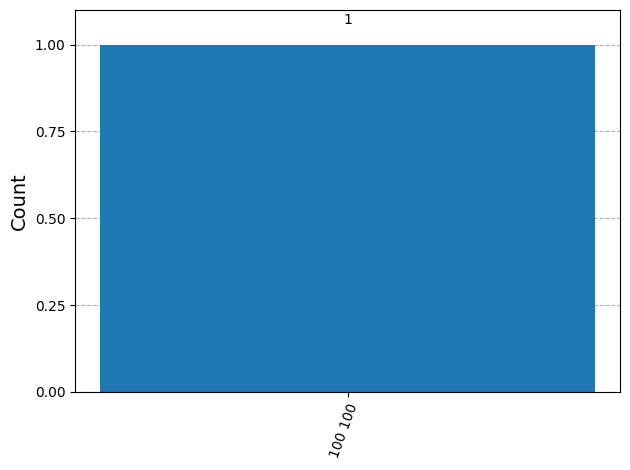

In [4]:
QFT.measure_all() #Measure circuit

qasm_sim = Aer.get_backend('qasm_simulator') #Init simulator
start_time = time.time()
result = qasm_sim.run(QFT, shots =1).result() #Capture result of runs
counts = result.get_counts()
print(f"Optimized sim time: {time.time() - start_time:.10f}s")
plot_histogram(counts) #Plot

Optimized sim time: 0.0040919781s


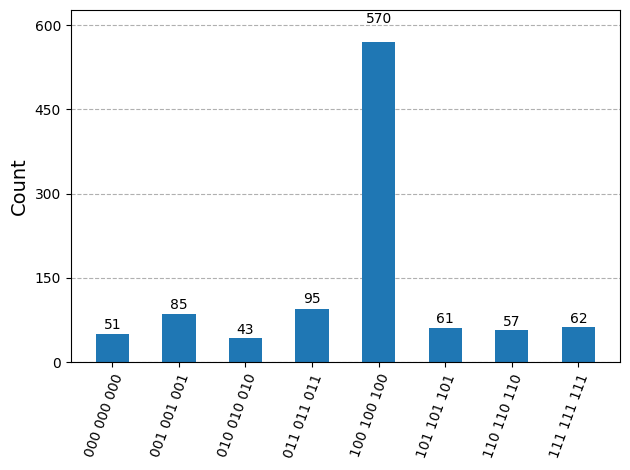

In [5]:
QFT.measure_all() #Measure circuit

qasm_sim = Aer.get_backend('qasm_simulator') #Init simulator
start_time = time.time()
result = qasm_sim.run(QFT, shots =1024).result() #Capture result of runs
counts = result.get_counts()
print(f"Optimized sim time: {time.time() - start_time:.10f}s")
plot_histogram(counts) #Plot